Here we replicate the phase diagram from the lecture notes on 'Quantum Phase Transitions' by Thomas Vojta.

We consider the Transverse ﬁeld Ising model
$$ H = -J \sum_{\langle i j\rangle} Z_i Z_j -h \sum_i X_i$$

In [2]:
import qutip as qp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def create_hamiltonian(field, coupling, n_qubits, pbc=True):
    hamiltonian = 0.

    for i in range(n_qubits):
        op = [qp.qeye(2)]*n_qubits
        op[i] = qp.sigmax()
        hamiltonian += - field * qp.tensor(op)

    for i in range(n_qubits-1):
        op = [qp.qeye(2)]*n_qubits
        op[i] = qp.sigmaz()
        op[i+1] = qp.sigmaz()
        hamiltonian -= coupling * qp.tensor(op)
    if pbc:
        op = [qp.sigmaz()] + [qp.qeye(2)]*(n_qubits-2) + [qp.sigmaz()]
        hamiltonian -= coupling * qp.tensor(op)

    return hamiltonian

In [4]:
field_strgs = np.linspace(0, 2, 20)
results = []

for field in field_strgs:
    ham = create_hamiltonian(field=field, coupling=1.0, n_qubits=8, pbc=True)
    eigs = np.linalg.eigh(ham.full())
    results.append(eigs.eigenvalues)

results = np.array(results)

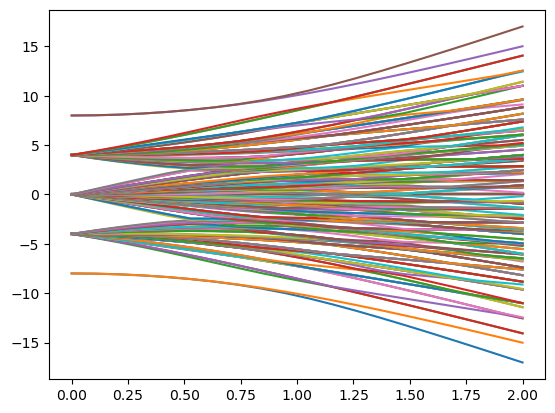

In [5]:
for res in results.T:
    plt.plot(field_strgs, res)

In [6]:
field_strgs = np.linspace(0., 1.5, 20)
results_qbs = []

for n_qbits in [4, 5, 6, 7, 8]:
    results = []
    for field in field_strgs:
        ham = create_hamiltonian(field=field, coupling=1.0, n_qubits=n_qbits, pbc=True)
        eigs = np.linalg.eigh(ham.full())
        results.append(eigs.eigenvalues[:2] / n_qbits)

    results_qbs.append(np.array(results))

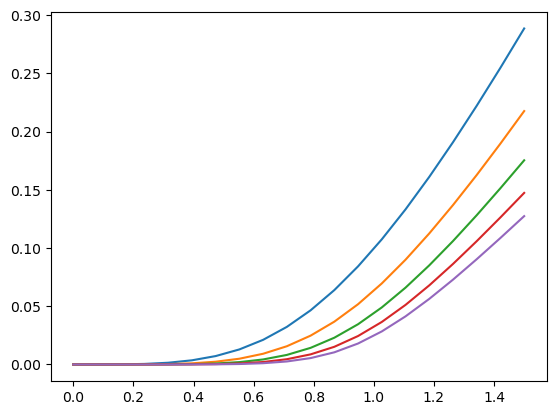

In [7]:
for res_qb in results_qbs:
    # plt.plot(field_strgs, res_qb[:, 0])
    # plt.plot(field_strgs, res_qb[:, 1])
    plt.plot(field_strgs, res_qb[:, 1]-res_qb[:, 0])
    

In [8]:
results_qbs = []
n_qbits = np.array([4, 5, 6, 7, 8, 9, 10])

for n_qbit in n_qbits:
    ham = create_hamiltonian(field=1.0, coupling=1.0, n_qubits=n_qbit, pbc=True)
    eigs = np.linalg.eigh(ham.full())
    results_qbs.append(eigs.eigenvalues[:2] / n_qbit)

results_qbs = np.array(results_qbs)

Text(0.5, 0, '1/n')

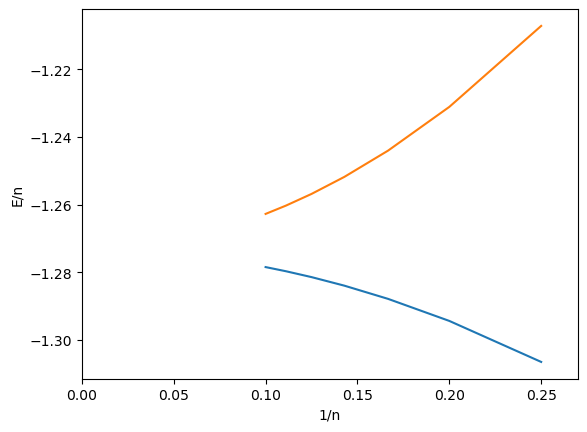

In [9]:
xs = 1. / n_qbits
plt.plot(xs, results_qbs[:, 0], label='e0')
plt.plot(xs, results_qbs[:, 1], label='e1')

plt.xlim(0, xs[0]+0.02)
plt.ylabel("E/n")
plt.xlabel("1/n")